<a href="https://colab.research.google.com/github/doundo/ICT_voice_detect/blob/hibigs_detect/ICT_bigs_detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!pip install noisereduce
#!pip install --upgrade librosa
#!pip install --upgrade librosa numba
!pip install fastdtw
!pip install torch torchaudio --upgrade

[15703.052531389909, 19040.421306662414, 11471.22756713353]
20050.841350950468
fin: dtw_results.csv


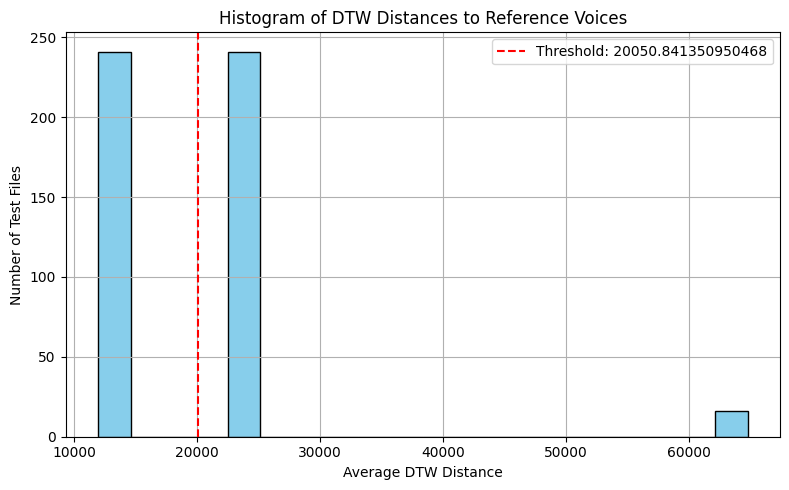

In [ ]:
import os
import torch
import torchaudio
import torchaudio.transforms as T
import pandas as pd
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import numpy as np
import matplotlib.pyplot as plt

ref_folder = '/content/drive/MyDrive/ICT_voice_detect_project/my_hibigs'
test_folder = '/content/drive/MyDrive/ICT_voice_detect_project/hibigs_test'
output_csv = '/content/drive/MyDrive/ICT_voice_detect_project/hibigs_test/MFCC_results.csv'

#오디오를 16kHz로 통일
sample_rate = 16000
n_mfcc = 13
max_len = 300 #프레임 기준

#MFCC 변환 정의
mfcc_transform = T.MFCC(
    sample_rate=sample_rate,
    n_mfcc=n_mfcc,
    melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
)

#MFCC 시퀀스 추출 함수 부
def extract_mfcc_sequence_torch(path):
    waveform, sr = torchaudio.load(path)
    if sr != sample_rate:
        resampler = T.Resample(sr, sample_rate)
        waveform = resampler(waveform)
    mfcc = mfcc_transform(waveform)
    return mfcc.squeeze(0).T.numpy()

#정규화 함수
def extract_mfcc_sequence_torch(path, max_len=300):
    waveform, sr = torchaudio.load(path)

    # 스테레오 → 모노 (2채널 평균)
    if waveform.size(0) > 1:
        waveform = waveform.mean(dim=0, keepdim=True)  # [1, T]

    if sr != sample_rate:
        resampler = T.Resample(sr, sample_rate)
        waveform = resampler(waveform)

    mfcc = mfcc_transform(waveform)  # [1, n_mfcc, time]
    mfcc = mfcc.squeeze(0).T         # [time, n_mfcc]

    # 패딩 (자르지 않음)
    if mfcc.size(0) < max_len:
        pad = torch.zeros((max_len - mfcc.size(0), mfcc.size(1)))
        mfcc = torch.cat([mfcc, pad], dim=0)

    return mfcc.numpy()




# 기준 음성 로딩
ref_mfccs = []
for fname in os.listdir(ref_folder):
    if fname.endswith('.wav'):
        mfcc = extract_mfcc_sequence_torch(os.path.join(ref_folder, fname), max_len)
        ref_mfccs.append(mfcc)

# 기준 음성 간 거리 계산
self_distances = []
for i in range(len(ref_mfccs)):
    for j in range(i + 1, len(ref_mfccs)):
        dist, _ = fastdtw(ref_mfccs[i], ref_mfccs[j], dist=euclidean)
        self_distances.append(dist)

print(self_distances)
avg_self_dist = np.mean(self_distances) if self_distances else 0
threshold = avg_self_dist + np.std(self_distances) * 1.5
print(threshold)

# 테스트 음성 판별
results = []
dist_list=[]
for fname in os.listdir(test_folder):
    if not fname.endswith('.wav'):
        continue
    test_mfcc = extract_mfcc_sequence_torch(os.path.join(test_folder, fname), max_len)
    dists = [fastdtw(test_mfcc, ref, dist=euclidean)[0] for ref in ref_mfccs]
    avg_dist = np.mean(dists)
    dist_list.append(avg_dist)
    label = "my_voice" if avg_dist < threshold else "other_voice"
    results.append((fname, avg_dist, label))

# 결과 출력
df = pd.DataFrame(results, columns=["file_name", "FastDTW_mean_distance", "result"])
df.to_csv('/content/drive/MyDrive/ICT_voice_detect_project/dtw_results.csv', index=False)
print("fin: dtw_results.csv")
df

# 거리 분포 시각화
plt.figure(figsize=(8, 5))
plt.hist(dist_list, bins=20, color='skyblue', edgecolor='black')
plt.axvline(x=threshold, color='red', linestyle='--', label=f"Threshold: {threshold}")
plt.title("Histogram of DTW Distances to Reference Voices")
plt.xlabel("Average DTW Distance")
plt.ylabel("Number of Test Files")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()